# EGM 722 Project Notebook: Greenspace Analysis (Draft)

## Introduction

Welcome to my project notebook! This will take you through the code required to perform analysis on the amount of Greenspace available in Northern Ireland. 

The code will consist of 3 main parts:
1. **Importing the necessary modules**
2. **Loading the data and setting the CRS**
3. **Carrying out the analysis**

**Please Note:** This is currently only a draft - parts may be messy or incomplete!

## Part 1: Preparing Data

To start the project, we first need to import the necessary modules, followed by the data.

In [1]:
#Import the required modules
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from cartopy.feature import ShapelyFeature
import cartopy.crs as ccrs
import numpy as np
import rasterio as rio
import rasterstats
import rasterio.features
from rasterio.features import geometry_mask

In [2]:
# Load and name the data layers
greenspace = gpd.read_file(os.path.abspath('data_files/Greenspace_Phase2_06052022.shp'))
lgd2014 = gpd.read_file(os.path.abspath('data_files/LGD2014.shp'))
dea2014 = gpd.read_file(os.path.abspath('data_files/dea2014.shp'))
dz2021 = gpd.read_file(os.path.abspath('data_files/DZ2021.shp'))
sdz2021 = gpd.read_file(os.path.abspath('data_files/SDZ2021.shp'))
settlements2015 = gpd.read_file(os.path.abspath('data_files/settlements-2015-above-500-threshold.shp'))


In [3]:
# View the first 5 rows of the greenspace data to check if it loaded in correctly
greenspace

,SourceID,GUID,Name,Source,Category,Type,PaidAccess,Area_Ha,Verified,ShowOnMap,ORNI_ID,DataAdded,SiteCreate,geometry
0,NaN,68d2df20-1512-4218-a759-1000732e93b0,Conservation Volunteers NI,LPS and Outscape,Amenity Greenspace,Community Garden,No,0.668234,Approximated,Yes,51,2022-09-21,Pre 2023,"POLYGON Z ((335088.596 367463.239 0, 334995.26..."
1,NaN,7b20f220-682e-4566-a4fe-2513cc65ed6e,Lough Shore Park,Antrim and Newtownabbey Borough Council,Parks and Gardens,Public Park,No,6.598284,Approximated,Yes,61,2022-09-21,Pre 2023,"POLYGON Z ((313511.357 386601.644 0, 313465.51..."
2,NaN,8a4b8a31-eba9-4e7a-b8d5-cea0724d848d,Ardmore Recreation Centre,"Armagh City, Banbridge and Craigavon Borough C...",Amenity Greenspace,Playing Fields,No,2.969549,Approximated,Yes,67,2022-09-21,Pre 2023,"POLYGON Z ((289345.456 344248.549 0, 289352.83..."
3,NaN,36f2a040-649c-4eb5-9174-7b25c083f489,Clare Glen - Phase 3 - Link Footpath/River Wal...,"Armagh City, Banbridge and Craigavon Borough C...",Woodland,Woodland,No,3.396109,Approximated,Yes,69,2022-09-21,Pre 2023,"POLYGON Z ((303292.783 345625.097 0, 303291.38..."
4,NaN,2f586e46-b9ee-4d13-83b1-9b254fa3a698,"Folly Glen, Armagh","Armagh City, Banbridge and Craigavon Borough C...",Woodland,Woodland,No,7.849400,Approximated,Yes,70,2022-09-21,Pre 2023,"MULTIPOLYGON Z (((288701.465 343901.121 0, 288..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1486,NaN,NaN,Connswater Community Greenway,Belfast City Council,Amenity Greenspace,Public Open Space,NaN,7.872995,NaN,Yes,0,1899-12-30,Pre 2023,"MULTIPOLYGON Z (((338098.461 372640.049 0, 338..."
1487,NaN,NaN,Twinbrook Wildlife Park,Belfast City Council,Amenity Greenspace,Public Open Space,NaN,1.161658,NaN,Yes,0,1899-12-30,NaN,"MULTIPOLYGON Z (((328479.994 368987.968 0, 328..."
1488,NaN,NaN,Drumcoo Playing Fields,Mid Ulster District Council,Amenity Greenspace,Playing Fields,NaN,3.022465,NaN,Yes,0,1899-12-30,Pre 2023,"POLYGON Z ((279812.935 363921.041 0, 279810.78..."
1489,NaN,NaN,Battery Harbour Park,Mid Ulster District Council,Amentiy Greenspace,Public Open Space,NaN,1.769502,NaN,Yes,0,1899-12-30,NaN,"POLYGON Z ((296502.851 377054.243 0, 296514.15..."


The greenspace polygon has multiple 'Polgon Z' and 'Multipolygon Z' types. To avoid any problems with clipping we will get rid of these by converting the greenspace layer to a singlepart layer.

In [4]:
# Convert the greenspace polygons to single parts polygons and view the dataset
greenspace_sp=greenspace.explode(column=None)
greenspace_sp

,SourceID,GUID,Name,Source,Category,Type,PaidAccess,Area_Ha,Verified,ShowOnMap,ORNI_ID,DataAdded,SiteCreate,geometry
0,NaN,68d2df20-1512-4218-a759-1000732e93b0,Conservation Volunteers NI,LPS and Outscape,Amenity Greenspace,Community Garden,No,0.668234,Approximated,Yes,51,2022-09-21,Pre 2023,"POLYGON Z ((335088.596 367463.239 0, 334995.26..."
1,NaN,7b20f220-682e-4566-a4fe-2513cc65ed6e,Lough Shore Park,Antrim and Newtownabbey Borough Council,Parks and Gardens,Public Park,No,6.598284,Approximated,Yes,61,2022-09-21,Pre 2023,"POLYGON Z ((313511.357 386601.644 0, 313465.51..."
2,NaN,8a4b8a31-eba9-4e7a-b8d5-cea0724d848d,Ardmore Recreation Centre,"Armagh City, Banbridge and Craigavon Borough C...",Amenity Greenspace,Playing Fields,No,2.969549,Approximated,Yes,67,2022-09-21,Pre 2023,"POLYGON Z ((289345.456 344248.549 0, 289352.83..."
3,NaN,36f2a040-649c-4eb5-9174-7b25c083f489,Clare Glen - Phase 3 - Link Footpath/River Wal...,"Armagh City, Banbridge and Craigavon Borough C...",Woodland,Woodland,No,3.396109,Approximated,Yes,69,2022-09-21,Pre 2023,"POLYGON Z ((303292.783 345625.097 0, 303291.38..."
4,NaN,2f586e46-b9ee-4d13-83b1-9b254fa3a698,"Folly Glen, Armagh","Armagh City, Banbridge and Craigavon Borough C...",Woodland,Woodland,No,7.849400,Approximated,Yes,70,2022-09-21,Pre 2023,"POLYGON Z ((288701.465 343901.121 0, 288688.70..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1487,NaN,NaN,Twinbrook Wildlife Park,Belfast City Council,Amenity Greenspace,Public Open Space,NaN,1.161658,NaN,Yes,0,1899-12-30,NaN,"POLYGON Z ((328479.994 368987.968 0, 328473.32..."
1487,NaN,NaN,Twinbrook Wildlife Park,Belfast City Council,Amenity Greenspace,Public Open Space,NaN,1.161658,NaN,Yes,0,1899-12-30,NaN,"POLYGON Z ((328487.187 369000.669 0, 328484.11..."
1488,NaN,NaN,Drumcoo Playing Fields,Mid Ulster District Council,Amenity Greenspace,Playing Fields,NaN,3.022465,NaN,Yes,0,1899-12-30,Pre 2023,"POLYGON Z ((279812.935 363921.041 0, 279810.78..."
1489,NaN,NaN,Battery Harbour Park,Mid Ulster District Council,Amentiy Greenspace,Public Open Space,NaN,1.769502,NaN,Yes,0,1899-12-30,NaN,"POLYGON Z ((296502.851 377054.243 0, 296514.15..."


In [5]:
# Finally, Ccheck the crs of each layer
layer_crs = {'greenspace_crs': [greenspace.crs], 'lgd2014_crs': [lgd2014.crs], 'dz2021_crs': [dz2021.crs], 'sdz2021_crs': [sdz2021.crs], 'settlements2015_crs': [settlements2015.crs]}
crs_table = pd.DataFrame(data=layer_crs)
crs_table

,greenspace_crs,lgd2014_crs,dz2021_crs,sdz2021_crs,settlements2015_crs
0,EPSG:29902,EPSG:29902,EPSG:29902,EPSG:29902,EPSG:29902


## Part 2: Greenspace Analysis

This next part of the notebook will demonstrate some analysis using the greenspace data and boundaries provided.

Using the data, we can find:
1. What areas have the highest/lowest coverage of greenspace: at SDZ level and DEA, and per 1000 people.
2. What areas are closest to a greenspaces? How many greenspaces are within a particular distance of an area?
3. What areas have the largest amount of land available for potential greenspaces?


### Part 2.1. Calculating coverage

Before the area of greenspace found within each SDZ, LGD, DEA etc. can be calculated, it would be useful to calculate the area of each polygon to a standard unit (Km^2).
This is where the first function will be defined, one that calculates the area of each polygon, in Km2 and adds it on as a new column to the table.

**Note**: This step is particularly important for the recently exploded greenspace layer, as the area of each single-part polygon created will need to be calculated in order to calculate their coverage.

In [7]:
def area_calc(layer, col_name):
    """Caluclates the area of each polygon in the layer and returns a total.
    
    Parameters 
    layer : input polygon layer
    col_name : name of the area column

    Returns : sum_area_SQKM
        Prints the total area of the polygons in squared kilometers
    """

    layer[col_name] = layer['geometry'].area/1e6 # Create a new column calculating the area of each polygon in squared kilometers

    sum_area_SQKM = layer[col_name].sum() # Calculate the total area of the dataset
    print(f'The total area of this dataset is {sum_area_SQKM:.2f} kilometers squared')

In [10]:
#test area_calc function on greenspace layer and display the results
area_calc(greenspace_sp, 'greenspace_area_SQKM')
dea2014.head(6)

The total area of this dataset is 875.94 kilometers squared


,OBJECTID,DEA,popn,Shape_Leng,Shape_Area,geometry
0,1.0,MACEDON,19846,17542.729894,1.005002e+07,"POLYGON ((334156.322 383816.138, 334159.203 38..."
1,2.0,AIRPORT,23143,100844.338308,2.937776e+08,"POLYGON ((326291.638 387137.93, 326300.102 387..."
2,3.0,ANTRIM,23459,24142.561884,2.350514e+07,"POLYGON ((315209.815 389900.74, 315233.431 389..."
3,4.0,BALLYCLARE,18104,53023.566135,7.796712e+07,"POLYGON ((328093.219 395176.251, 328095.159 39..."
4,5.0,THREE MILE WATER,20412,32513.229485,1.879701e+07,"POLYGON ((329144.24 387618.703, 329146.815 387..."
5,6.0,GLENGORMLEY URBAN,19737,16736.203775,9.227570e+06,"POLYGON ((331206.514 384197.638, 331212.837 38..."


In [11]:
#add a area SQKM column to the remainder of the datasets and find their total area
area_calc(dz2021, 'dz_area')
area_calc(sdz2021, 'sdz_area')
area_calc(dea2014, 'dea_area')
area_calc(lgd2014, 'lgd_area')
area_calc(settlements2015, 'settlement_area')

The total area of this dataset is 13628.31 kilometers squared
The total area of this dataset is 13628.31 kilometers squared
The total area of this dataset is 14315.28 kilometers squared
The total area of this dataset is 14315.28 kilometers squared
The total area of this dataset is 639.99 kilometers squared


Now we are ready to start analysing.

In [12]:
def coverage_calc(layer, clipping_feature, orig_area):
    """
    Clips the selected greensapce layer to the selected dataset, creates a grouped gdf based on the individual features, which is then joined to the original selected dataset to calculate the % coverage

    Parameters: 
    layer - the selected layer or dataset to be clipped to
    clipping feature - the column name of the clipping dataset, must be a unique
    oirg_area - the calculated area column in the clipping dataset

    Returns:
    Output table - joined table of the original layer with information on its total coverage of greenspace
    """
    if layer[clipping_feature].is_unique == False:
        raise Exception('Clipping features must be unique.') # Raises an error if non unique features are used for the clipping
    
    clipped = [] # Create an empty list
    for selected_areas in layer[clipping_feature]: #iterate over each unique value in the clipping features
        tmp_clip = gpd.clip(greenspace_sp, layer[layer[clipping_feature] == selected_areas]) # clip the greenspace layer by each feature
        tmp_clip['greenspace_area_SQKM'] = tmp_clip['geometry'].area/1e6 # calculate the resulting area of the clipped greenspace polygons
        tmp_clip[clipping_feature] = selected_areas # set the name for each feature
    
        clipped.append(tmp_clip) # append the clipped GeoDataframe to the created list

    clipped_gdf = gpd.GeoDataFrame(pd.concat(clipped, ignore_index=True)) # createa new geodataframe by combining the clipped geodataframe
    
    grouped_gdf = pd.DataFrame(index=layer[clipping_feature]) # Creates a grouped dataframe series that sums the total area of greenspace in the clipped layer
    grouped_gdf['greenspace_coverage_SQKM'] = clipped_gdf.groupby([clipping_feature])['greenspace_area_SQKM'].sum()

    output_table = pd.merge(layer, grouped_gdf, on = clipping_feature) # Joins the grouped data frame to the original dataset
    output_table['pc_coverage'] = output_table['greenspace_coverage_SQKM'] / output_table[orig_area] * 100 # calculates a new column to show the percentage of the area covered by greenspace

    return output_table

In [13]:
dz_coverage = coverage_calc(dz2021, 'DZ2021_nm', 'dz_area') # Use the coverage_calc function to calculate the coverage of greenspace for each DZ
dz_coverage.sort_values(by=['pc_coverage'], ascending=False).head(10) # display the top 10 dz's in terms of greenspace coverage

,DZ2021_cd,DZ2021_nm,SDZ2021_cd,SDZ2021_nm,DEA2014_cd,DEA2014_nm,LGD2014_cd,LGD2014_nm,Area_ha,Perim_km,geometry,dz_area,greenspace_coverage_SQKM,pc_coverage
795,N20000796,Castle_D1,N21000182,Castle_D,N10000304,Castle,N09000003,Belfast,298.46,8.41,"POLYGON ((331437.798 378646.074, 331439.229 37...",2.984553,2.446236,81.963209
3116,N20003117,Slieve_Gullion_D3,N21000697,Slieve_Gullion_D,N10001006,Slieve Gullion,N09000010,"Newry, Mourne and Down",57.94,3.50,"POLYGON ((305465.34 327714.575, 305388.347 327...",0.579385,0.439901,75.925547
1838,N20001839,Ballyarnett_J3,N21000420,Ballyarnett_J,N10000501,Ballyarnett,N09000005,Derry City and Strabane,27.40,2.41,"POLYGON ((241841.396 420187.044, 241865.969 42...",0.274048,0.201154,73.400979
859,N20000860,Titanic_C1,N21000199,Titanic_C,N10000310,Titanic,N09000003,Belfast,33.08,2.77,"POLYGON ((337008.798 375374.767, 337031.89 375...",0.330761,0.239522,72.415471
427,N20000428,Craigavon_B4,N21000095,Craigavon_B,N10000203,Craigavon,N09000002,"Armagh City, Banbridge and Craigavon",210.59,9.85,"POLYGON ((306227.519 357663.286, 306226.044 35...",2.105869,1.508563,71.636112
733,N20000734,Oldpark_G1,N21000167,Oldpark_G,N10000308,Oldpark,N09000003,Belfast,27.85,2.87,"POLYGON ((332628.785 376683.797, 332627.225 37...",0.278546,0.196987,70.719523
542,N20000543,Lurgan_R5,N21000121,Lurgan_R,N10000206,Lurgan,N09000002,"Armagh City, Banbridge and Craigavon",30.48,2.48,"POLYGON ((307401.359 357091.064, 307400 357090...",0.304825,0.213284,69.969372
1773,N20001774,Foyleside_A5,N21000405,Foyleside_A,N10000504,Foyleside,N09000005,Derry City and Strabane,24.57,2.66,"POLYGON ((241742.624 419240.041, 241741.339 41...",0.245672,0.166478,67.764240
1056,N20001057,Lisnasharragh_K1,N21000245,Lisnasharragh_K,N10000307,Lisnasharragh,N09000003,Belfast,18.44,1.79,"POLYGON ((335043.014 371199.345, 334950.835 37...",0.184398,0.120281,65.228911
1735,N20001736,The_Moor_A2,N21000397,The_Moor_A,N10000506,The Moor,N09000005,Derry City and Strabane,53.26,4.04,"POLYGON ((242239.7 417267.53, 242249.872 41726...",0.532649,0.341210,64.059125


In [14]:
sdz_coverage = coverage_calc(sdz2021, 'SDZ2021_nm', 'sdz_area') # Use the coverage_calc function to calculate the coverage of greenspace for each SDZ
sdz_coverage.sort_values(by=['pc_coverage'], ascending=False).head(10) # display the top 10 sdz's in terms of greenspace coverage

,SDZ2021_cd,SDZ2021_nm,DEA2014_cd,DEA2014_nm,LGD2014_cd,LGD2014_nm,Area_ha,Perim_km,geometry,sdz_area,greenspace_coverage_SQKM,pc_coverage
181,N21000182,Castle_D,N10000304,Castle,N09000003,Belfast,333.13,10.77,"POLYGON ((331438.077 378645.335, 331437.798 37...",3.331262,2.446789,73.449311
303,N21000304,Black_Mountain_D,N10000302,Black Mountain,N09000003,Belfast,1045.38,14.89,"POLYGON ((326989.873 371971.843, 326989.422 37...",10.453750,5.786514,55.353477
39,N21000040,Macedon_D,N10000106,Macedon,N09000001,Antrim and Newtownabbey,102.88,5.93,"POLYGON ((332838.844 382336.503, 332851.15 382...",1.028766,0.489044,47.536964
198,N21000199,Titanic_C,N10000310,Titanic,N09000003,Belfast,53.53,3.98,"POLYGON ((336993.97 375471.742, 337078.525 375...",0.535307,0.239818,44.800130
396,N21000397,The_Moor_A,N10000506,The Moor,N09000005,Derry City and Strabane,80.45,5.03,"POLYGON ((242366.593 416934.847, 242330.709 41...",0.804487,0.358711,44.588771
821,N21000822,Bangor_Central_H,N10001102,Bangor Central,N09000011,Ards and North Down,92.13,5.17,"POLYGON ((350082.257 381197.298, 350082.697 38...",0.921279,0.389291,42.255480
696,N21000697,Slieve_Gullion_D,N10001006,Slieve Gullion,N09000010,"Newry, Mourne and Down",114.51,6.90,"POLYGON ((304651.842 328037.507, 304653.673 32...",1.145072,0.483570,42.230521
262,N21000263,Botanic_P,N10000303,Botanic,N09000003,Belfast,97.71,5.77,"POLYGON ((334937.872 371298.609, 334935.086 37...",0.977143,0.402043,41.144777
166,N21000167,Oldpark_G,N10000308,Oldpark,N09000003,Belfast,62.24,4.88,"POLYGON ((333252.27 376235.914, 333254.795 376...",0.622425,0.250728,40.282384
277,N21000278,Balmoral_F,N10000301,Balmoral,N09000003,Belfast,310.65,10.98,"POLYGON ((334998.922 370728.779, 335000 370722...",3.106533,1.236478,39.802514


In [15]:
dea_coverage = coverage_calc(dea2014, 'DEA', 'dea_area') # Use the coverage_calc function to calculate the coverage of greenspace for each DEA
dea_coverage.sort_values(by=['pc_coverage'], ascending=False).head(10) # display the top 10 sdz's in terms of greenspace coverage

,OBJECTID,DEA,popn,Shape_Leng,Shape_Area,geometry,dea_area,greenspace_coverage_SQKM,pc_coverage
14,15.0,BLACK MOUNTAIN,36632,21602.087604,1.853540e+07,"POLYGON ((328066.726 375507.412, 328069.124 37...",18.535403,6.353951,34.280083
20,21.0,BALMORAL,25136,23372.845954,1.614716e+07,"POLYGON ((332796.68 371100.345, 332803.389 371...",16.147157,3.429759,21.240640
0,1.0,MACEDON,19846,17542.729894,1.005002e+07,"POLYGON ((334156.322 383816.138, 334159.203 38...",10.050021,1.907861,18.983647
64,65.0,THE MOURNES,29445,128143.251804,3.396828e+08,"POLYGON ((328107.882 336658.528, 328115.273 33...",339.682801,61.134952,17.997659
18,19.0,CASTLE,32277,23744.546554,1.936035e+07,"POLYGON ((334071.541 379980.088, 334096.675 37...",19.360352,3.251503,16.794648
30,31.0,LIMAVADY,16439,87602.429588,1.935636e+08,"POLYGON ((266062.087 439140.001, 266067.334 43...",193.563579,30.091680,15.546148
16,17.0,COURT,32643,19729.961595,1.092835e+07,"POLYGON ((328461.23 376973.926, 328462.499 376...",10.928352,1.687048,15.437348
27,28.0,THE GLENS,17320,189575.079101,5.298492e+08,"MULTIPOLYGON (((303851.853 445529.153, 303852....",529.849160,80.385221,15.171341
38,39.0,ERNE WEST,14770,191648.247253,7.726392e+08,"POLYGON ((212306.572 360153.771, 214784.724 35...",772.639168,114.847491,14.864311
35,36.0,DERG,18908,142671.928180,3.889629e+08,"POLYGON ((233271.988 397461.269, 233279.563 39...",388.962900,53.804479,13.832805


In [16]:
lgd_coverage = coverage_calc(lgd2014, 'LGDNAME', 'lgd_area') # Use the coverage_calc function to calculate the coverage of greenspace for each LGD
lgd_coverage.sort_values(by=['pc_coverage'], ascending=False).head(10) # display the top 10 sdz's in terms of greenspace coverage

,OBJECTID,LGDNAME,LGDCode,popn,Shape_Leng,Shape_Area,geometry,lgd_area,greenspace_coverage_SQKM,pc_coverage
2,3.0,Belfast,N09000003,337885,65905.220983,1.377021e+08,"POLYGON ((334071.541 379980.088, 334096.675 37...",137.702072,20.517916,14.900223
3,4.0,Causeway Coast and Glens,N09000004,143541,381602.781803,1.983852e+09,"MULTIPOLYGON (((297026.984 446000.593, 297033....",1983.851819,198.972460,10.029603
5,6.0,Fermanagh and Omagh,N09000006,115794,426211.823548,3.005966e+09,"POLYGON ((266554.895 392093.167, 266557.237 39...",3005.965778,286.400462,9.527735
9,10.0,Newry Mourne and Down,N09000010,178794,380041.040234,1.681856e+09,"POLYGON ((341276.618 362805.051, 341283.866 36...",1681.856446,117.673445,6.996640
4,5.0,Derry City and Strabane,N09000005,150134,271234.988347,1.248976e+09,"POLYGON ((247533.964 424601.021, 247536.214 42...",1248.976336,76.646643,6.136757
8,9.0,Mid Ulster,N09000009,145391,318235.783575,1.955057e+09,"POLYGON ((294150.193 412224.918, 294156.626 41...",1955.056614,73.207589,3.744525
7,8.0,Mid and East Antrim,N09000008,137427,234832.258324,1.061065e+09,"POLYGON ((329896.206 424716.479, 329900.103 42...",1061.065214,30.279666,2.853705
10,11.0,Ards and North Down,N09000011,159893,204719.717118,5.666282e+08,"MULTIPOLYGON (((353045.141 383916.202, 353043....",566.628185,11.889053,2.098211
1,2.0,Armagh City Banbridge and Craigavon,N09000002,209276,242967.696647,1.435980e+09,"POLYGON ((311885.478 366349.627, 311904.219 36...",1435.980451,29.361744,2.044718
0,1.0,Antrim and Newtownabbey,N09000001,141428,165113.558771,7.278895e+08,"POLYGON ((319598.922 397397.797, 319595.68 397...",727.889478,12.425218,1.707020


Create a map showing the DEAs with the largest percentage cover of greenspaces

In [40]:
def generate_handles(labels, colors, edge='k', alpha=1):
    """
    Generate matplotlib patch handles to create a legend of each of the features in the map.

    Parameters:
    
    labels - list(str)
        the text labels of the features to add to the legend

    colors - list(matplotlib color)
        the colors used for each of the features included in the map.

    edge - matplotlib color (default: 'k')
        the color to use for the edge of the legend patches.

    alpha - float (default: 1.0)
        the alpha value to use for the legend patches.

    Returns: 
    
    handles - list(matplotlib.patches.Rectangle)
        the list of legend patches to pass to ax.legend()
    """
    lc = len(colors)  # get the length of the color list
    handles = [] # create an empty list
    for ii in range(len(labels)): # for each label and color pair that we're given, make an empty box to pass to our legend
        handles.append(mpatches.Rectangle((0, 0), 1, 1, facecolor=colors[ii % lc], edgecolor=edge, alpha=alpha))
    return handles

# adapted this question: https://stackoverflow.com/q/32333870
# answered by SO user Siyh: https://stackoverflow.com/a/35705477
def scale_bar(ax, length=20, location=(0.92, 0.95)):
    
    """
    Create a scale bar in a cartopy GeoAxes.

    Parameters

    ax - cartopy.mpl.geoaxes.GeoAxes
        the cartopy GeoAxes to add the scalebar to.

    length - int, float (default 20)
        the length of the scalebar, in km

    location - tuple(float, float) (default (0.92, 0.95))
        the location of the center right corner of the scalebar, in fractions of the axis.

    Returns:
    ax - cartopy.mpl.geoaxes.GeoAxes
        the cartopy GeoAxes object

    """
    x0, x1, y0, y1 = ax.get_extent() # get the current extent of the axis
    sbx = x0 + (x1 - x0) * location[0] # get the right x coordinate of the scale bar
    sby = y0 + (y1 - y0) * location[1] # get the right y coordinate of the scale bar

    ax.plot([sbx, sbx-length*1000], [sby, sby], color='k', linewidth=4, transform=ax.projection) # plot a thick black line
    ax.plot([sbx-(length/2)*1000, sbx-length*1000], [sby, sby], color='w', linewidth=2, transform=ax.projection) # plot a white line from 0 to halfway

    ax.text(sbx, sby-(length/4)*1000, f"{length} km", ha='center', transform=ax.projection, fontsize=6) # add a label at the right side
    ax.text(sbx-(length/2)*1000, sby-(length/4)*1000, f"{int(length/2)} km", ha='center', transform=ax.projection, fontsize=6) # add a label in the center
    ax.text(sbx-length*1000, sby-(length/4)*1000, '0 km', ha='center', transform=ax.projection, fontsize=6) # add a label at the left side

    return ax

In [ ]:
ni_utm = ccrs.UTM(29) # create a Universal Transverse Mercator reference system to transform our data.
ccrs.CRS(greenspace.crs) # create a cartopy CRS representation of the CRS associated with the greenspace dataset

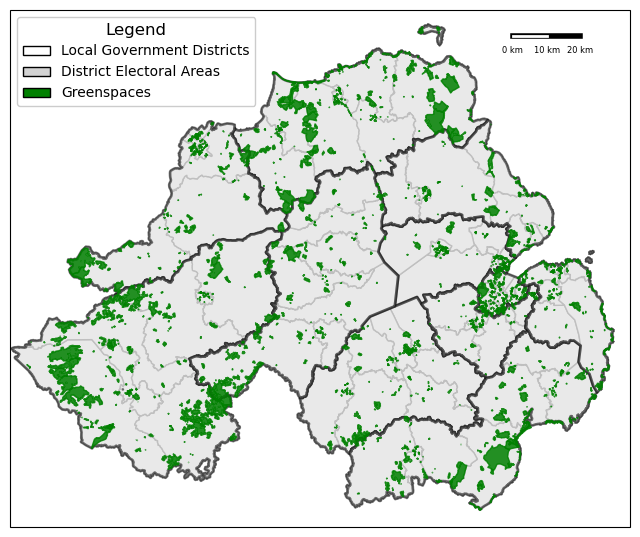

In [41]:
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ni_utm)

# Add DEAs to the map 
DEAs = ShapelyFeature(dea_coverage['geometry'], ni_utm, edgecolor = 'grey', facecolor = 'lightgray', linewidth = 1)
ax.add_feature(DEAs)   

# Add LGDs to the map
LGDs = ShapelyFeature(lgd2014['geometry'], ni_utm, edgecolor = 'k', facecolor = 'w', linewidth = 2, alpha=0.5)
ax.add_feature(LGDs)

#Add Greenspaces to the map
Greenspaces = ShapelyFeature(greenspace['geometry'], ni_utm, edgecolor = 'g', facecolor ='g', alpha=0.85)
ax.add_feature(Greenspaces)    
                                      
xmin, ymin, xmax, ymax = greenspace.total_bounds # using the boundary of the shapefile features, zoom the map to our area of interest
ax.set_extent([xmin-5000, xmax+5000, ymin-5000, ymax+5000], crs=ni_utm) # we re-order the coordinates to work with set_extent.

# Generate handles for each layer
lgd_handles = generate_handles(['LGDNAME'], ['w']) 
dea_handles = generate_handles(['DEA'], ['lightgray'])
greenspace_handles = generate_handles(['Name'], ['g'])

# Create the legend using the handles
handles = lgd_handles + dea_handles + greenspace_handles 
labels = ['Local Government Districts', 'District Electoral Areas', 'Greenspaces']

leg = ax.legend(handles, labels, title='Legend', title_fontsize=12, fontsize=10, loc='upper left', frameon=True, framealpha=1) # Add legend to the map

scale_bar(ax) # add a scale bar to the map

fig.savefig('map.png', bbox_inches='tight', dpi=300) #save figure to current folder

### Part 2.2. Finding Distances

For the next part of the analysis, will demonstrate how python can be used to calculate distances between greenspaces and the data zones (DZ). This will consist of: 

a) A buffer analysis, creating a function that allows you to easily calculate the number of greenspaces within a specified distance of your chosen location.
b) An interactive map, that shows the distance to the nearest greenspace for each DZ in the country.

In [6]:
#First check if any centroids do not fit within the settlement area
settlements2015.loc[~settlements2015['geometry'].contains(settlements2015.centroid)]

,Code,Name,Band,DT_20MIN,DT_30MIN,UR_ex,OccHH_ex,UR_ap,OccHH_ap,geometry
23,N11000085,MILLTOWN (BENBURB),H,Y,Y,108.0,39.0,108.0,39.0,"MULTIPOLYGON (((280562.585 351306.808, 280580...."
30,N11000023,BALLYHALBERT,G,N,N,1026.0,407.0,1040.0,414.0,"POLYGON ((363382.554 364070.777, 363389.608 36..."
34,N11000118,DUNAGHY,H,Y,Y,391.0,149.0,391.0,149.0,"MULTIPOLYGON (((297252.61 426241.837, 297314.1..."
38,N11000008,MONEYGLASS,H,N,Y,103.0,38.0,103.0,38.0,"POLYGON ((301694.028 393314.942, 301700.362 39..."
42,N11000402,DRUMSURN,H,Y,Y,459.0,161.0,452.0,159.0,"MULTIPOLYGON (((272069.047 417384.408, 272082...."
...,...,...,...,...,...,...,...,...,...,...
487,N11000561,ROUGHFORT,H,Y,Y,215.0,86.0,215.0,86.0,"MULTIPOLYGON (((327013.931 384022.779, 327017...."
494,N11000572,ORLOCK,H,Y,Y,126.0,50.0,128.0,51.0,"POLYGON ((355753.587 383596.517, 355754.888 38..."
499,N11000441,LOWER BROOMHEDGE,H,Y,Y,239.0,80.0,239.0,80.0,"POLYGON ((321293.411 362730.793, 321309.277 36..."
506,N11000422,DRUMBEG,H,Y,Y,813.0,321.0,817.0,323.0,"MULTIPOLYGON (((330603.615 367044.403, 330603...."


Because some of our centroids (66) do not fit inside the boundaries of our settlements, it would make more sense to use a representative point of each settlement

Now let's write this as a function, that counts the number of greeenspaces within a specified radius of a chosen area

In [162]:
def find_gspace(layer, name_col, area, buffer_dist):
    """Counts the number of Greenspaces that are within a specified radius of your chosen feature

    Parameters:
    layer - chosen layer to measure distances from
    name_col - column name containing the reference name of chosesn feature
    area - name of chosen feature e.g. BELFAST CITY note: case sensitive
    buffer distance - selected buffer distance (in metres)
    
    Returns:
    A list count of the greenspaces within specified distance, grouped by category

    """
    #Create a copy of the dataset, and calculate representative points
    layer_pt = layer.copy()
    layer_pt['geometry'] = layer.representative_point()

    selected_area = layer_pt.loc[layer_pt[name_col] == area] # select the area to perform the analysis

    pt_buffer = selected_area.buffer(buffer_dist) # buffer the chosen representative point, by the specified distance (in metres)

    available_greenspace = greenspace.loc[greenspace['geometry'].within(pt_buffer.iloc[0])] # select the greenspace polygons within the chosen buffered point

    return available_greenspace.groupby(['Category'])['Name'].count() # return the a count of the greenspaces available, grouped by category


This provides a quick way to estimate an area's proximity to greenspaces, for example, the cell below shows the number of greenspaces within 10km of the village Donaghcloney.

**Note:** At larger scales, this estimation will become less accurate for example, measuring the greenspaces availabe within 1km of an area near the center of Belfast will not represenet the number of greenspaces available within a km for ALL of Belfast!

In [131]:
find_gspace(settlements2015, 'Name', 'DONAGHCLONEY', 10000)

Category
Amenity Greenspace    17
Parks and Gardens      8
Woodland               3
Name: Name, dtype: int64

In [167]:
find_gspace(settlements2015, 'Name', 'COLERAINE', 2000)

Series([], Name: Name, dtype: int64)

In [178]:
find_gspace(sdz2021, 'SDZ2021_nm', 'Oldpark_G', 1000)

Category
Amenity Greenspace    1
Parks and Gardens     2
Name: Name, dtype: int64

While this is useful for a quick analysis on each individual area, this could be expanded to find the number of greenspaces within proximity of each settlement.

In [118]:
def buffer_analysis(layer, name_col, dist, dist_col): # Define a function to count the number of greenspaces within a specified distance

    '''
    Performs a distance within spatial join to count the number of greenspaces within distance of a specified area, then returns a the a merged copy of the original data showing counts

    Parameters:

    layer - input layer to count from
    name_col - column name containing the name of each chosen feature
    dist - buffer distance, in m
    dist_col - name of the returned column

    Returns:

    dist_table - a copy of the original layer, merged to include greenspace counts for specified distance

    '''

    within_dist= gpd.sjoin(layer, greenspace[['geometry']], how='inner', predicate='dwithin', distance=(dist)) # spatial join using the distance within function, to join the number of greenspaces to each settlement

    #create a grouped geodataframe counting the number of greenspace
    num_gspace = within_dist.groupby(name_col)
    num_gspace_df = pd.DataFrame(index=layer[name_col])
    num_gspace_df[dist_col] = num_gspace[name_col].count()

    counts = num_gspace_df.fillna(0) # fill any NaN values with 0
    dist_table = layer.merge(counts, left_on=[name_col], right_on=[name_col]) # merge to a new copy of the original layer

    return dist_table



In [117]:
# Use buffer_analysis to find the number of greenspaces within 300m, 2km, 5km and 10km of settlement areas
gspace_300m=buffer_analysis(settlements2015, 'Name', 300, 'gSpaces_within_300m')
gspace_2km=buffer_analysis(settlements2015, 'Name', 2000, 'gSpaces_within_2km')
gspace_5km=buffer_analysis(settlements2015, 'Name', 5000, 'gSpaces_within_5km')
gspace_10km=buffer_analysis(settlements2015, 'Name', 10000, 'gSpaces_within_10km')

#Merge each result to the main settlement table, on the settlement codes
settlements_dists = pd.merge(settlements2015, gspace_300m[['Name', 'gSpaces_within_300m']], on= 'Name', how= 'left')
settlements_dists = pd.merge(settlements_dists, gspace_2km[['Name', 'gSpaces_within_2km']], on= 'Name', how= 'left')
settlements_dists= pd.merge(settlements_dists, gspace_5km[['Name', 'gSpaces_within_5km']], on= 'Name', how= 'left')
settlements_dists = pd.merge(settlements_dists, gspace_10km[['Name', 'gSpaces_within_10km']], on= 'Name', how= 'left')

settlements_dists

,Code,Name,Band,DT_20MIN,DT_30MIN,UR_ex,OccHH_ex,UR_ap,OccHH_ap,geometry,gSpaces_within_300m,gSpaces_within_2km,gSpaces_within_5km,gSpaces_within_10km
0,N11000199,DUNNAMORE,H,Y,Y,119.0,35.0,119.0,35.0,"MULTIPOLYGON (((268852.639 381005.968, 268889....",0.0,0.0,4.0,9
1,N11000015,BALLYBARNES,H,Y,Y,242.0,101.0,243.0,102.0,"POLYGON ((345603.666 375407.884, 345605.848 37...",0.0,3.0,39.0,120
2,N11000121,LOUGHGUILE,H,N,Y,396.0,128.0,396.0,128.0,"POLYGON ((308240.408 425324.409, 308241.835 42...",0.0,0.0,2.0,11
3,N11000265,BRYANSFORD,H,N,Y,306.0,114.0,309.0,115.0,"POLYGON ((334307.413 333016.05, 334309.718 333...",1.0,2.0,19.0,31
4,N11000636,SION MILLS,G,Y,Y,1903.0,769.0,1907.0,770.0,"POLYGON ((233835.1 392685.125, 233833.438 3926...",2.0,4.0,18.0,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522,N11000457,UPPER BALLINDERRY,H,Y,Y,226.0,95.0,226.0,95.0,"POLYGON ((316438.311 367603.169, 316434.283 36...",0.0,0.0,4.0,38
523,N11000153,CARRICKFERGUS,C,Y,Y,27903.0,11536.0,27998.0,11562.0,"POLYGON ((339592.352 389235.293, 339607.19 389...",17.0,20.0,41.0,138
524,N11000443,LURGANVILLE,H,Y,Y,87.0,32.0,87.0,32.0,"POLYGON ((317538.491 359477.921, 317540.763 35...",0.0,0.0,4.0,50
525,N11000151,BELFAST CITY,A,Y,Y,280211.0,120341.0,280138.0,120285.0,"MULTIPOLYGON (((332185.45 381234.249, 332185.4...",122.0,229.0,281.0,372


While this information is useful by itself, it could be summarised by local government district to show the typical number of greenspaces available for a settlement. 
To show this, the settlement layer must be joined to the LGD layer. Since settlement boundaries may overlap, deriving representative points again will ensure a cleaner join.

In [116]:
settlement_pt = settlements_dists.copy() # make a copy of the dataset
settlement_pt['geometry']=settlement_pt['geometry'].representative_point() # overwrite the geometry to representative points

contains = gpd.sjoin(lgd_copy, settlement_pt, how='inner', predicate='contains') # peform a spatial join to find what lgd each settlement belongs to

columns = ['gSpaces_within_300m', 'gSpaces_within_2km', 'gSpaces_within_5km', 'gSpaces_within_10km'] # columns to summarize

lgd_summary_gSpace = contains.groupby(['LGDNAME'], as_index=False)[columns].median() # Create a grouped geodataframe, finding the median of each column
lgd_summary_gSpace['num_settlements'] = contains.groupby(['LGDNAME'])['Code'].nunique().values # include a column counting the number of settlements

lgd_summary_gSpace

,LGDNAME,gSpaces_within_300m,gSpaces_within_2km,gSpaces_within_5km,gSpaces_within_10km,num_settlements
0,Antrim and Newtownabbey,0.0,1.0,9.5,61.5,26
1,Ards and North Down,1.0,3.0,12.5,47.5,38
2,Armagh City Banbridge and Craigavon,0.0,1.0,4.5,30.5,78
3,Belfast,26.0,44.0,123.0,229.5,6
4,Causeway Coast and Glens,1.0,2.0,7.0,24.0,63
5,Derry City and Strabane,0.0,2.0,7.0,22.0,41
6,Fermanagh and Omagh,0.0,1.0,5.0,19.0,60
7,Lisburn and Castlereagh,0.0,1.0,27.0,101.0,41
8,Mid Ulster,0.0,1.0,7.0,24.0,70
9,Mid and East Antrim,1.0,3.0,11.0,41.5,28


In [125]:
#write this to a csv file and save in output folder
lgd_summary_gSpace.to_csv('output_files/lgd_summar_gSpace.csv')

Another way to estimate each areas proximity to a greenspace is by calculating each area's distance to a greenspace. The dz layer will be used to demonstrate this, and create an interactive map showing how far each area is from a greenspace.

In [126]:
for ind, row in dz2021.iterrows(): # iterrate over each row in dz
    pt = row['geometry'].centroid # generate a centroid as pt
    distances = greenspace.distance(pt) # calculate the distance from each centroid to each greenspace

    min_ind = distances.argmin() # get the index of the mininum value
    min_dist = distances.min() # get the minimum distace

    dz2021.loc[ind, 'Nearest_gSpace'] = greenspace.loc[min_ind].Name # Report the name of the nearest greenspace
    dz2021.loc[ind, 'Distance_km'] = min_dist/1000 # create a new column calculating the minimum distance in km

dz2021.Distance_km = dz2021.Distance_km.round(2) # round the distance column to 2.dp

The next part of the code will count the number of greenspaces in each dz, using a spatial join:

In [127]:
joined = gpd.sjoin(dz2021, greenspace, how='inner', lsuffix='left', rsuffix='right') # create a gdf using a spatial join to list the dz each greenspace polygon is found in

num_gspace = joined.groupby('DZ2021_nm') # group by dz
num_space_df = pd.DataFrame(index=dz2021['DZ2021_nm']) # create a grouped dataframe that counts the number of occurrences (greenspaces) in each dz as a column "Num_gSpaces"
num_space_df['Num_gSpaces'] = num_gspace['DZ2021_nm'].count()

to_join=num_space_df.fillna(0) # set any NaN values to equal = 0 to ensure the mergre will work

merged = dz2021.merge(to_join, left_on='DZ2021_nm', right_on='DZ2021_nm') # megre the dataframe to the original dz2021 layer, using the dz names
merged # show the result

,DZ2021_cd,DZ2021_nm,SDZ2021_cd,SDZ2021_nm,DEA2014_cd,DEA2014_nm,LGD2014_cd,LGD2014_nm,Area_ha,Perim_km,geometry,Nearest_gSpace,Distance_km,Num_gSpaces
0,N20000001,Dunsilly_A1,N21000001,Dunsilly_A,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,2070.68,22.93,"POLYGON ((319580.264 396993.361, 319573.665 39...",Tardree,1.01,1.0
1,N20000002,Dunsilly_B1,N21000002,Dunsilly_B,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,1253.69,19.14,"POLYGON ((323772.447 393378.876, 323764.289 39...",NaN,2.88,0.0
2,N20000003,Dunsilly_A2,N21000001,Dunsilly_A,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,792.91,15.50,"POLYGON ((305377.841 395055.242, 305378.841 39...",NaN,3.60,0.0
3,N20000004,Dunsilly_A3,N21000001,Dunsilly_A,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,1100.52,17.90,"POLYGON ((311500.959 395028.333, 311510.728 39...",NaN,3.95,0.0
4,N20000005,Dunsilly_B2,N21000002,Dunsilly_B,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,1740.82,21.93,"POLYGON ((323772.447 393378.876, 323784.201 39...",Tardree,2.57,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3775,N20003776,Ards_Peninsula_N2,N21000850,Ards_Peninsula_N,N10001101,Ards Peninsula,N09000011,Ards and North Down,30.72,3.00,"POLYGON ((359752.134 351035.673, 359759.06 351...",Cloughy Road Playing Fields,0.20,1.0
3776,N20003777,Ards_Peninsula_N3,N21000850,Ards_Peninsula_N,N10001101,Ards Peninsula,N09000011,Ards and North Down,7.41,1.21,"POLYGON ((359710.93 351090.923, 359759.06 3510...",Ann Street,0.26,0.0
3777,N20003778,Ards_Peninsula_N4,N21000850,Ards_Peninsula_N,N10001101,Ards Peninsula,N09000011,Ards and North Down,18.28,3.06,"POLYGON ((359863.411 350571.537, 359828.275 35...",Ann Street,0.39,0.0
3778,N20003779,Ards_Peninsula_N5,N21000850,Ards_Peninsula_N,N10001101,Ards Peninsula,N09000011,Ards and North Down,13.15,2.40,"POLYGON ((359671.758 349967.45, 359669.807 349...",Nugents Wood,0.71,0.0


In [1]:
m = merged.explore('Distance_km', # show the Distance column
                   cmap='Blues_r', # Set the colourmap to blues
                   legends_kwds={'caption': 'Distance to nearest greenspace in km'} # add the legents
                                 )

greenspace.explore('Category', # Plot the greenspace layer showing the different categories
                   m=m, # add to existing map
                   cmap = 'Set2', # set colourmap to set 2
                   popup= True, # enable pop ups
                   legend_kwds= {'caption': 'Greenspace Category'} #add legend
                  )

NameError: name 'merged' is not defined

In [180]:
m.save('output_files/greenspace_imap.html')

### Part 2.3. Potential Greenspace

This next part of the analysis will involve calculating the area of potential greenspace for each settlement. It will use a landcover layer of 100m resolution to help identify potential areas of greenspace, and exclude any areas that area already designated greenspaces.

First, the raster layer must be prepared by loading the layer and defining the land cover class names and creating a dict object of key/value pairs

In [16]:
# define the landcover class names in a list
names = ['Broadleaf woodland', 'Coniferous woodland', 'Arable', 'Improved grassland', 'Semi-natural grassland',
         'Mountain, heath, bog', 'Saltwater', 'Freshwater', 'Coastal', 'Built-up areas and gardens']

values = range(1, 11) # get numbers from 1-10, corresponding to the landcover values

landcover_names = dict(zip(values, names)) # create a landcover dict of value/name pairs

#load the landcover raster and read the data
with rio.open('data_files/LCM2015_Aggregate_100m.tif') as dataset:
    xmin, ymin, xmax, ymax = dataset.bounds
    crs = dataset.crs
    landcover2015 = dataset.read(1)
    affine_tfm = dataset.transform

print(dataset.crs) # check the crs

EPSG:32629


With the raster loaded and classes defined, it's needs reprojected to match the other shapefiles used in the analysis : EPSG 29902

In [19]:
#Reproject the Raster to EPSG 29902
dst_crs = 'epsg:29902' # Define the destination crs (EPSG: 29902)

with rio.open('data_files/LCM2015_Aggregate_100m.tif') as src: # set the original raster as the source dataset
    transform, width, height = rio.warp.calculate_default_transform( # find the new transform, width and height attribute values for the reprojected raster
        src.crs, dst_crs, src.width, src.height, *src.bounds)
    
    kwargs = src.meta.copy() # copy the meta attribute from the source dataset
    
    kwargs.update({ # changes the attributes of the dict
    'crs': dst_crs,
    'transform': transform,
    'width': width,
    'height': height
    })

    with rio.open('data_files/LCM2015_Aggregate_100m_reproj.tif', 'w', **kwargs) as dst: # writes the reprojected raster as a new file 
        for ind in range(1, src.count +1): # reproject each band from the source dataset to the reporjected raster, using a nearest-neighbour resampling
            rio.warp.reproject(
                source=rio.band(src, ind),
                destination=rio.band(dst, ind),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=rio.warp.Resampling.nearest
            )

In [17]:
with rio.open('data_files/LCM2015_Aggregate_100m_reproj.tif') as dataset: # Load and read the newly reprojected raster as dataset
    xmin, ymin, xmax, ymax = dataset.bounds
    crs = dataset.crs
    landcover2015_reproj = dataset.read(1)
    affine_tfm = dataset.transform

    print(dataset.crs) # check the crs to verify the reprojection worked

EPSG:29902


This next function will be able to take an array (in this case the raster), and return a dict object containing the number of pixels for each of the unique values (classes) in the array.

In [26]:
def count_unique(array, names, nodata=0):
    '''
    Count the unique elements of an array.
    
    Parameters
    param array: Input array
    param names: a dict of key/value pairs that map raster values to a name
    param nodata: nodata value to ignore in the counting

    Returns:
    returns count_dict: a dictionary of unique values and counts
    '''
    count_dict = dict() # create the output dict
    for val in np.unique(array): # iterate over the unique values for the raster
        if val == nodata: # if the value is equal to our nodata value, move on to the next one
            continue
        count_dict[names[val]] = np.count_nonzero(array == val)
    return count_dict # return the now-populated output dict

In [19]:
landcover_count = count_unique(landcover2015_reproj, landcover_names) # use the function to find the number of pixels in each landcover class
print(landcover_count) # print the result

{'Broadleaf woodland': np.int64(40312), 'Coniferous woodland': np.int64(73388), 'Arable': np.int64(90731), 'Improved grassland': np.int64(834491), 'Semi-natural grassland': np.int64(75987), 'Mountain, heath, bog': np.int64(179935), 'Saltwater': np.int64(16991), 'Freshwater': np.int64(60877), 'Coastal': np.int64(14084), 'Built-up areas and gardens': np.int64(56597)}


Now that the classes defined and labelled, a reclassified copy of the dataset will be made to show only the desired classes (areas suitable for greenspace): broadleaf and coniferous woodlands and semi-natural grassland

In [20]:
landcover_rc = landcover2015_reproj.copy() # make a copy of the reprojected raster to reclassify

landcover_rc[np.where((landcover_rc == 1) | (landcover_rc == 2) | (landcover_rc == 5))] = 1 #Suitable
landcover_rc[np.where(
    (landcover_rc == 3) |
    (landcover_rc == 4) |
    (landcover_rc == 6) |
    (landcover_rc == 7) |
    (landcover_rc == 8) |
    (landcover_rc == 9) |
    (landcover_rc == 10) |
    (landcover_rc == 11))] = 2 #Unsuitable

class_names = { # define the class names
    1: "Suitable",
    2: "Unsuitable"
}

landcover_count_rc = count_unique(landcover_rc, class_names) # count the number of cells belonging to each class
print(landcover_count_rc) # print the result

{'Suitable': np.int64(189687), 'Unsuitable': np.int64(1253706)}


When looking for potential greenspaces, areas that are already allocated greenspaces should be excluded. This will be done by masking the greenspace layer

In [21]:
green_mask = geometry_mask(
    geometries=greenspace.geometry, # Use geometries from greenspace layer
    transform=affine_tfm, # geotransform the new raster
    invert = True, # invert, so values within polygons will = true
    out_shape=landcover_rc.shape)

landcover_rc[green_mask] = 2 # select cells within masked cells (where cells are true) and assign the value of 0

With the areas of current greenspace excluded, it is now possible to find potential greenspace each settlement has using zonal statistics of a polygon. This will be done to calculate the potential for areas within 0.3, 1, 2, and 5 km, of a chosen polygon layer.
In order to repeat this process for the different buffer zones, a function will be defined to calculate the potential greenspace for a selected layer, in kilometers squared:

In [22]:
# Write this as a function

def potential_gp_calc (input_layer, name_col, buffer_dist, suitable_area_col, unsuitable_area_col):
    '''
    Count the number of pixels suitable/unsuitable suitable for greenspace, within a distance of chosen features

    Parameters:
    input_layer: the layer to used to count the potential greenspaces from
    name_col: column containing names or IDs of the chosen features e.g. settlement names or ward codes
    buffer_dist: the selected search distance, in metres
    suitable_area_col: output column name for storing the calculated suitable area, in kilometers squared
    unsuitable_area_col: output column name for storing the calculated unsuitable area, in kilometers squared

    returns:
    buffered: output copy GeoDataFrame of original layer, with calculated areas and pixel counts attached

    '''
    
    buffered = input_layer.copy()
    buffered['geometry'] = buffered.geometry.buffer(buffer_dist)

    potential_gs = rasterstats.zonal_stats(buffered,
                                           landcover_rc,
                                           affine = affine_tfm,
                                           categorical = True,
                                           category_map = class_names,
                                           nodata = 0
                                          )
    names = buffered[name_col]

    layer_dict = dict(zip(names, potential_gs))

    for ind, row in buffered.iterrows(): #use iterrows to iterate oer the rows of the table
        layer_data = layer_dict[row[name_col]] # get the suitability count for this settlement
        for name in class_names.values(): # iterate over each of the suitability classes
            if name in layer_data.keys(): # check that name is a key of settlment_data
                buffered.loc[ind, name] = layer_data[name] # add the suitability count to a new colomn
            else:
                buffered.loc[ind, name] = 0 #if name is not present, value should be 0

    #Add columns showing the area of suitable and unsuitable
    buffered[suitable_area_col] = buffered['Suitable']*0.01
    buffered[unsuitable_area_col] = buffered['Unsuitable']*0.01

    return buffered


Now this function will be used to find the area of suitable/unsuitable greenspaces within 300m, 1km, 2km and 5km, of each settlement area

In [25]:
#Use this function to find areas within 300m, 1, 2, and 5 km
potential_gp_300m = potential_gp_calc(settlements2015, 'Name', 300, 'Suitable_area_300m', 'Unsuitable_area_300m')
potential_gp_1km = potential_gp_calc(settlements2015, 'Name', 1000, 'Suitable_area_1km', 'Unsuitable_area_1km')
potential_gp_2km = potential_gp_calc(settlements2015, 'Name', 2000, 'Suitable_area_2km', 'Unsuitable_area_2km')
potential_gp_5km = potential_gp_calc(settlements2015, 'Name', 5000, 'Suitable_area_5km', 'Unsuitable_area_5km')

#Merge each result to the main settlement table, on the settlement codes
settlements_merged = pd.merge(settlements2015, potential_gp_300m[['Code', 'Suitable_area_300m', 'Unsuitable_area_300m']], on= 'Code', how= 'left')
settlements_merged = pd.merge(settlements_merged, potential_gp_1km[['Code', 'Suitable_area_1km', 'Unsuitable_area_1km']], on= 'Code', how= 'left')
settlements_merged = pd.merge(settlements_merged, potential_gp_2km[['Code', 'Suitable_area_2km', 'Unsuitable_area_2km']], on= 'Code', how= 'left')
settlements_merged = pd.merge(settlements_merged, potential_gp_5km[['Code', 'Suitable_area_5km', 'Unsuitable_area_5km']], on= 'Code', how= 'left')

settlements_merged

,Code,Name,Band,DT_20MIN,DT_30MIN,UR_ex,OccHH_ex,UR_ap,OccHH_ap,geometry,Suitable_area_300m,Unsuitable_area_300m,Suitable_area_1km,Unsuitable_area_1km,Suitable_area_2km,Unsuitable_area_2km,Suitable_area_5km,Unsuitable_area_5km
0,N11000199,DUNNAMORE,H,Y,Y,119.0,35.0,119.0,35.0,"MULTIPOLYGON (((268852.639 381005.968, 268889....",0.00,1.26,0.01,5.84,0.32,17.36,3.95,86.89
1,N11000015,BALLYBARNES,H,Y,Y,242.0,101.0,243.0,102.0,"POLYGON ((345603.666 375407.884, 345605.848 37...",0.06,1.08,0.22,5.23,0.85,16.08,7.64,81.31
2,N11000121,LOUGHGUILE,H,N,Y,396.0,128.0,396.0,128.0,"POLYGON ((308240.408 425324.409, 308241.835 42...",0.00,1.18,0.04,5.49,1.00,16.08,5.56,83.78
3,N11000265,BRYANSFORD,H,N,Y,306.0,114.0,309.0,115.0,"POLYGON ((334307.413 333016.05, 334309.718 333...",0.01,1.30,0.10,5.83,0.72,17.19,6.75,80.99
4,N11000636,SION MILLS,G,Y,Y,1903.0,769.0,1907.0,770.0,"POLYGON ((233835.1 392685.125, 233833.438 3926...",0.10,2.57,0.12,8.46,0.26,22.07,1.06,88.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522,N11000457,UPPER BALLINDERRY,H,Y,Y,226.0,95.0,226.0,95.0,"POLYGON ((316438.311 367603.169, 316434.283 36...",0.10,0.85,0.69,4.36,2.34,13.89,7.63,79.72
523,N11000153,CARRICKFERGUS,C,Y,Y,27903.0,11536.0,27998.0,11562.0,"POLYGON ((339592.352 389235.293, 339607.19 389...",1.04,16.83,2.07,25.60,2.90,40.84,5.86,102.05
524,N11000443,LURGANVILLE,H,Y,Y,87.0,32.0,87.0,32.0,"POLYGON ((317538.491 359477.921, 317540.763 35...",0.05,0.64,0.27,4.10,0.67,14.20,3.94,80.19
525,N11000151,BELFAST CITY,A,Y,Y,280211.0,120341.0,280138.0,120285.0,"MULTIPOLYGON (((332185.45 381234.249, 332185.4...",5.75,93.60,10.09,125.58,14.91,172.51,24.53,343.27
